In [1]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install xgboost


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_regression
import xgboost as xg
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from imblearn.combine import SMOTEENN
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (roc_curve, precision_recall_curve, classification_report,
                             roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, ConfusionMatrixDisplay)
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score


## Loading the Dataset

In [4]:
air_health = pd.read_csv(r'C:\Users\Admin\Documents\data mining\air_quality_health_impact_data.csv')
air_health.head()

,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
0,1,187.270059,295.853039,13.038560,6.639263,66.161150,54.624280,5.150335,84.424344,6.137755,7,5,1,97.244041,0.0
1,2,475.357153,246.254703,9.984497,16.318326,90.499523,169.621728,1.543378,46.851415,4.521422,10,2,0,100.000000,0.0
2,3,365.996971,84.443191,23.111340,96.317811,17.875850,9.006794,1.169483,17.806977,11.157384,13,3,0,100.000000,0.0
3,4,299.329242,21.020609,14.273403,81.234403,48.323616,93.161033,21.925276,99.473373,15.302500,8,8,1,100.000000,0.0
4,5,78.009320,16.987667,152.111623,121.235461,90.866167,241.795138,9.217517,24.906837,14.534733,9,0,1,95.182643,0.0


In [5]:
# Basic information about the dataset
print("Dataset shape: ", air_health.shape)

Dataset shape:  (5811, 15)


In [6]:
print("\nFirst 5 rows: ")
print(air_health.head())


First 5 rows: 
   RecordID         AQI        PM10       PM2_5         NO2        SO2  \
0         1  187.270059  295.853039   13.038560    6.639263  66.161150   
1         2  475.357153  246.254703    9.984497   16.318326  90.499523   
2         3  365.996971   84.443191   23.111340   96.317811  17.875850   
3         4  299.329242   21.020609   14.273403   81.234403  48.323616   
4         5   78.009320   16.987667  152.111623  121.235461  90.866167   

           O3  Temperature   Humidity  WindSpeed  RespiratoryCases  \
0   54.624280     5.150335  84.424344   6.137755                 7   
1  169.621728     1.543378  46.851415   4.521422                10   
2    9.006794     1.169483  17.806977  11.157384                13   
3   93.161033    21.925276  99.473373  15.302500                 8   
4  241.795138     9.217517  24.906837  14.534733                 9   

   CardiovascularCases  HospitalAdmissions  HealthImpactScore  \
0                    5                   1          9

In [7]:
print("\nData types and null values:")
print(air_health.info())


Data types and null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5811 entries, 0 to 5810
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   RecordID             5811 non-null   int64  
 1   AQI                  5811 non-null   float64
 2   PM10                 5811 non-null   float64
 3   PM2_5                5811 non-null   float64
 4   NO2                  5811 non-null   float64
 5   SO2                  5811 non-null   float64
 6   O3                   5811 non-null   float64
 7   Temperature          5811 non-null   float64
 8   Humidity             5811 non-null   float64
 9   WindSpeed            5811 non-null   float64
 10  RespiratoryCases     5811 non-null   int64  
 11  CardiovascularCases  5811 non-null   int64  
 12  HospitalAdmissions   5811 non-null   int64  
 13  HealthImpactScore    5811 non-null   float64
 14  HealthImpactClass    5811 non-null   float64
dtypes: float6

In [8]:
print("\nDescriptive statistics")
print(air_health.describe())


Descriptive statistics
          RecordID          AQI         PM10        PM2_5          NO2  \
count  5811.000000  5811.000000  5811.000000  5811.000000  5811.000000   
mean   2906.000000   248.438476   148.654997   100.223714   102.293445   
std    1677.635538   144.777638    85.698500    58.096612    57.713175   
min       1.000000     0.005817     0.015848     0.031549     0.009625   
25%    1453.500000   122.951293    75.374954    49.435171    53.538538   
50%    2906.000000   249.127841   147.634997   100.506337   102.987736   
75%    4358.500000   373.630668   222.436759   151.340260   151.658516   
max    5811.000000   499.858837   299.901962   199.984965   199.980195   

               SO2           O3  Temperature     Humidity    WindSpeed  \
count  5811.000000  5811.000000  5811.000000  5811.000000  5811.000000   
mean     49.456838   149.312431    14.975500    54.776853     9.989177   
std      28.530329    86.534240    14.483067    26.020786     5.776950   
min       0.0

## **Data Preprocessing**

## a. Data cleaning:

### **Checking for missing values**

In [9]:
print("\nMissing values per column:")
print(air_health.isnull().sum())


Missing values per column:
RecordID               0
AQI                    0
PM10                   0
PM2_5                  0
NO2                    0
SO2                    0
O3                     0
Temperature            0
Humidity               0
WindSpeed              0
RespiratoryCases       0
CardiovascularCases    0
HospitalAdmissions     0
HealthImpactScore      0
HealthImpactClass      0
dtype: int64


## **Checking Outliers**
### **Using IQR method to find outliers**

In [10]:
# checking for outliers using IQR
out= air_health.drop(columns= ['RecordID', 'HealthImpactScore', 'HealthImpactClass'])

q1= out.quantile(0.25)
q3= out.quantile(0.75)
iqr= q3-q1

# detect outliers
is_outlier = (out< (q1-1.5 * iqr))| (out>(q3+1.5 * iqr))

# count how many outliers per column
outlier_counts = is_outlier.sum()

# count how many rows have any outiler
rows_with_any_outlier = is_outlier.any(axis=1).sum()

print("Outilers by feature:")
print(outlier_counts)

print("\nTotal rows with at least 1 outlier:")
print(rows_with_any_outlier)

Outilers by feature:
AQI                     0
PM10                    0
PM2_5                   0
NO2                     0
SO2                     0
O3                      0
Temperature             0
Humidity                0
WindSpeed               0
RespiratoryCases       42
CardiovascularCases    74
HospitalAdmissions     31
dtype: int64

Total rows with at least 1 outlier:
146


### **Boxplot showing outliers for selected features**

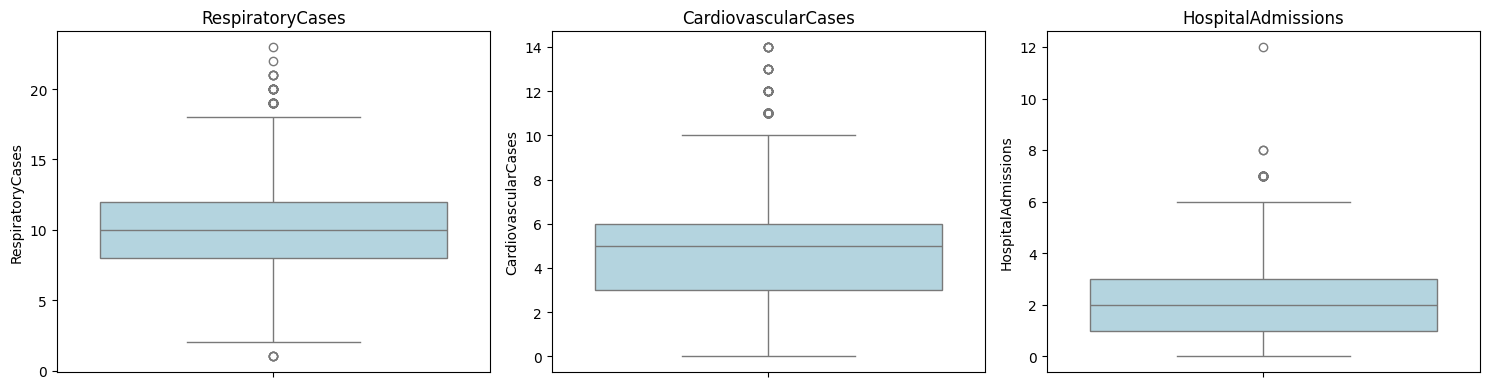

In [11]:
features= ['RespiratoryCases', 'CardiovascularCases', 'HospitalAdmissions']

plt.figure(figsize= (15,4))

for idx, feature in enumerate(features):
    plt.subplot(1,3, idx+1)
    sns.boxplot(y= air_health[feature], color= 'lightblue')
    plt.title(feature)

plt.tight_layout()
plt.show()

## **b. Data Transformation**

### **Applying Standardization (Z- score)**

In [12]:
df= air_health.copy()

# Drop ID and target columns
X= df.drop(columns= ['RecordID', 'HealthImpactScore', 'HealthImpactClass'])

# Scale numeric features
scaler= StandardScaler()
X_scaled= scaler.fit_transform(X)

# Recombine with targets
df_scaled= pd.DataFrame(X_scaled, columns= X.columns)
df_scaled['HealthImpactScore']= df['HealthImpactScore']
df_scaled['HealthImpactClass']= df['HealthImpactClass']
df_scaled

,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
0,-0.422535,1.717775,-1.500822,-1.657549,0.585544,-1.094322,-0.678448,1.139475,-0.666745,-0.950534,0.004969,-0.715701,97.244041,0.0
1,1.567495,1.138971,-1.553395,-1.489825,1.438687,0.234717,-0.927516,-0.304607,-0.946559,0.008250,-1.348455,-1.430664,100.000000,0.0
2,0.812063,-0.749340,-1.327427,-0.103549,-1.107022,-1.621528,-0.953334,-1.420905,0.202236,0.967033,-0.897314,-1.430664,100.000000,0.0
3,0.351540,-1.489470,-1.479565,-0.364923,-0.039723,-0.648948,0.479897,1.717872,0.919824,-0.630939,1.358392,-0.715701,100.000000,0.0
4,-1.177280,-1.536534,0.893208,0.328238,1.451539,1.068833,-0.397601,-1.148028,0.786911,-0.311345,-2.250738,-0.715701,95.182643,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5806,-0.534146,-1.603534,1.682875,0.976458,-1.111655,1.514658,1.545650,0.266379,-1.020012,1.286628,0.004969,-0.000738,100.000000,4.0
5807,1.673422,1.478400,-0.765163,0.520609,-0.705349,-0.476950,1.350455,-1.277869,-0.572432,-0.630939,0.456110,-0.000738,100.000000,3.0
5808,0.458697,-1.245897,1.454338,-0.349822,0.661730,-0.505554,0.552421,1.458528,-1.229038,0.647439,-1.348455,0.714225,100.000000,1.0
5809,-0.278783,0.196972,1.703405,-0.025942,1.336575,0.198287,1.458043,-1.112305,0.126932,-1.270128,-1.348455,0.714225,100.000000,4.0


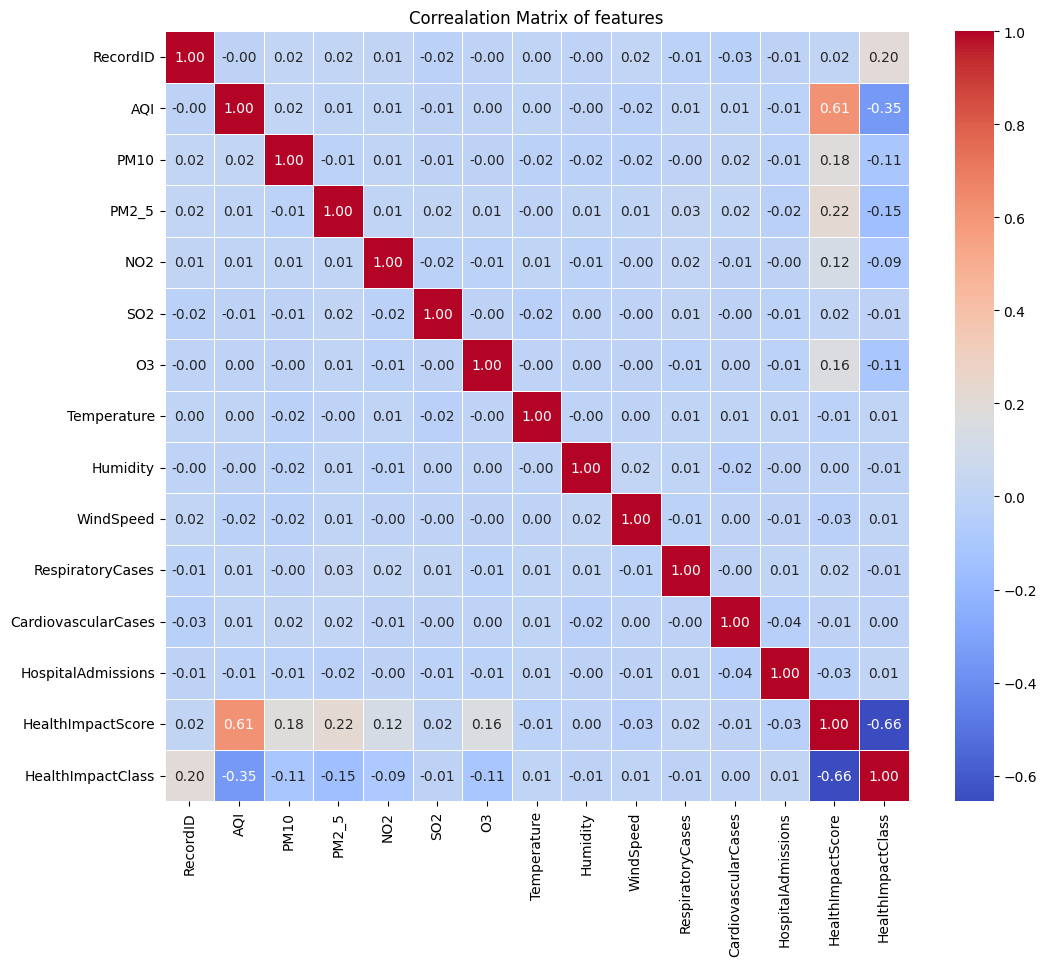

In [13]:
# Using numeric features only
corr_matrix= air_health.corr(numeric_only= True)

# Plotting heatmap
plt.figure(figsize= (12, 10))
sns.heatmap(corr_matrix,annot= True, cmap= 'coolwarm', fmt= ".2f", linewidths= 0.5)
plt.title('Correalation Matrix of features')
plt.show()

Correlation matrix shows that:
- HealthImpactScore is strongly affected by AQI, so that's important variable.
- HealthImpactClass may be derived from score, which gives the strong negative correlation.
- Pollutants like PM2.5, PM10, and NO2 have some influence on AQI and health metrices.
- Environmental conditions are not strongly related with health or pollutant levels.

## **c. Feature engineering**

In [14]:
# adding season labels based on temp (no date info)
def add_season(air_health):
    def get_season(temp):
        if temp >= 25:
            return 'Summer'
        elif temp >=15:
            return 'Spring'
        elif temp >= 5:
            return 'Fall'
        else:
            return 'Winter'

    air_health['Season']= air_health['Temperature'].apply(get_season)
    return air_health

air_health= add_season(air_health)

In [15]:
air_health.head()

,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass,Season
0,1,187.270059,295.853039,13.038560,6.639263,66.161150,54.624280,5.150335,84.424344,6.137755,7,5,1,97.244041,0.0,Fall
1,2,475.357153,246.254703,9.984497,16.318326,90.499523,169.621728,1.543378,46.851415,4.521422,10,2,0,100.000000,0.0,Winter
2,3,365.996971,84.443191,23.111340,96.317811,17.875850,9.006794,1.169483,17.806977,11.157384,13,3,0,100.000000,0.0,Winter
3,4,299.329242,21.020609,14.273403,81.234403,48.323616,93.161033,21.925276,99.473373,15.302500,8,8,1,100.000000,0.0,Spring
4,5,78.009320,16.987667,152.111623,121.235461,90.866167,241.795138,9.217517,24.906837,14.534733,9,0,1,95.182643,0.0,Fall


In [16]:
# adding pollution index that combines major pollutants

# PCA- based on pollution index
cols= ['PM2_5', 'NO2', 'SO2', 'O3']
X= air_health[cols]

# scale and reduce
X_scaled= StandardScaler().fit_transform(X)
pca= PCA (n_components=1)
air_health['PollutionIndex']= pca.fit_transform(X_scaled)

# check variance explained
print("Variance explained:", pca.explained_variance_ratio_[0])
print(air_health[['PollutionIndex']].head())

Variance explained: 0.2563982529325304
   PollutionIndex
0        0.517586
1        1.376235
2       -1.621961
3       -0.516208
4        1.372690


### **Encoding categorical variables**
As ML models can't understand categorical data, encoding is necessary.

In [17]:
# finding categorical column
cc= air_health.select_dtypes(include='object').columns.tolist()
print("Categorical columns: ", cc)

Categorical columns:  ['Season']


In [18]:
# One- hot encoding used in `Season`, as it's nominal categorical variable
air_health= pd.get_dummies(air_health, columns=['Season'], drop_first= True)
print(air_health.filter(like='Season').head())

   Season_Spring  Season_Summer  Season_Winter
0          False          False          False
1          False          False           True
2          False          False           True
3           True          False          False
4          False          False          False


 `drop_first= True` helps avoid redundant info in linear models. 
- here `fall` is used as reference or baseline i.e when all the other season columns are 0, it implies the record is **Fall**

## **2. EDA**

### **Checking class distribution for HealthImpactClass**

In [19]:
print("\nHealth Impact Class Distribution")
print(air_health['HealthImpactClass'].value_counts())


Health Impact Class Distribution
HealthImpactClass
0.0    4808
1.0     579
2.0     273
3.0      95
4.0      56
Name: count, dtype: int64


**INDEX**

0: `Very High` (HealthImpactScore >= 80)

1: `High` (60 <= HealthImpactScore < 80)

2: `Moderate` (40 <= HealthImpactScore < 60)

3: `Low` (20 <= HealthImpactScore < 40)

4: `Very Low` (HealthImpactScore < 20)


- 4808 samples fall into **"Very High"** category.
- Very few samples (95+56= 151) are in "Low" and "Very Low" categories.
- Thus, the distribution is heavily skewed as data is imbalance and bias toward "Very High" class.

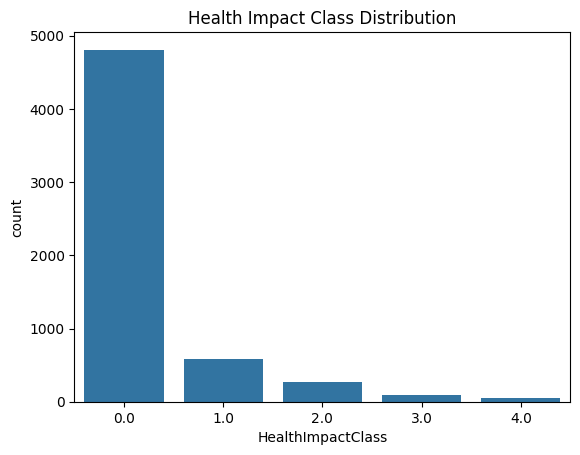

In [20]:
# Visualize the imbalance:
sns.countplot(x='HealthImpactClass', data=air_health)
plt.title('Health Impact Class Distribution')
plt.show()

### **Summary statistics**

In [21]:
summary_stats = air_health.describe()
print(summary_stats)

          RecordID          AQI         PM10        PM2_5          NO2  \
count  5811.000000  5811.000000  5811.000000  5811.000000  5811.000000   
mean   2906.000000   248.438476   148.654997   100.223714   102.293445   
std    1677.635538   144.777638    85.698500    58.096612    57.713175   
min       1.000000     0.005817     0.015848     0.031549     0.009625   
25%    1453.500000   122.951293    75.374954    49.435171    53.538538   
50%    2906.000000   249.127841   147.634997   100.506337   102.987736   
75%    4358.500000   373.630668   222.436759   151.340260   151.658516   
max    5811.000000   499.858837   299.901962   199.984965   199.980195   

               SO2           O3  Temperature     Humidity    WindSpeed  \
count  5811.000000  5811.000000  5811.000000  5811.000000  5811.000000   
mean     49.456838   149.312431    14.975500    54.776853     9.989177   
std      28.530329    86.534240    14.483067    26.020786     5.776950   
min       0.011023     0.001661    -9

### **Distribution plots of health cases and pollutants**

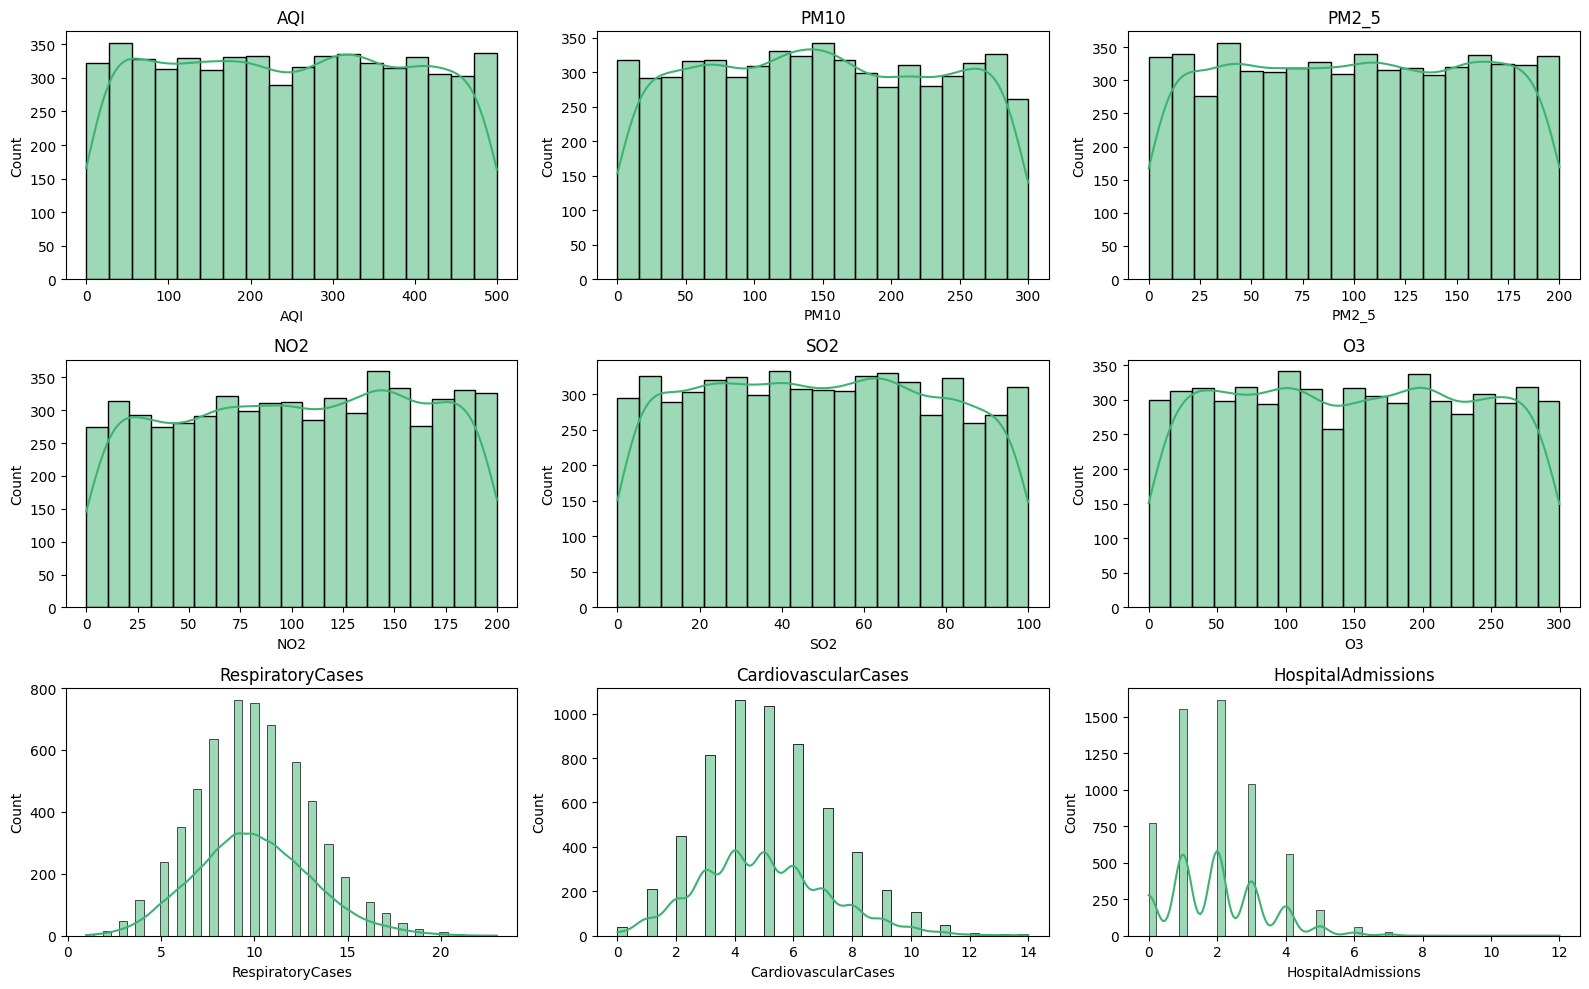

In [22]:
# histograms for air quality and health data
features= ['AQI', 'PM10', 'PM2_5', 'NO2', 'SO2', 'O3',
          'RespiratoryCases', 'CardiovascularCases', 'HospitalAdmissions']

plt.figure(figsize=(16,10))
for i, feature in enumerate(features):
    plt.subplot(3,3, i+1)
    sns.histplot(air_health[feature], kde=True, color= 'mediumseagreen')
    plt.title(feature)

plt.tight_layout()
plt.show()

### **Correlation heatmap of Pollutants and Health outcomes**

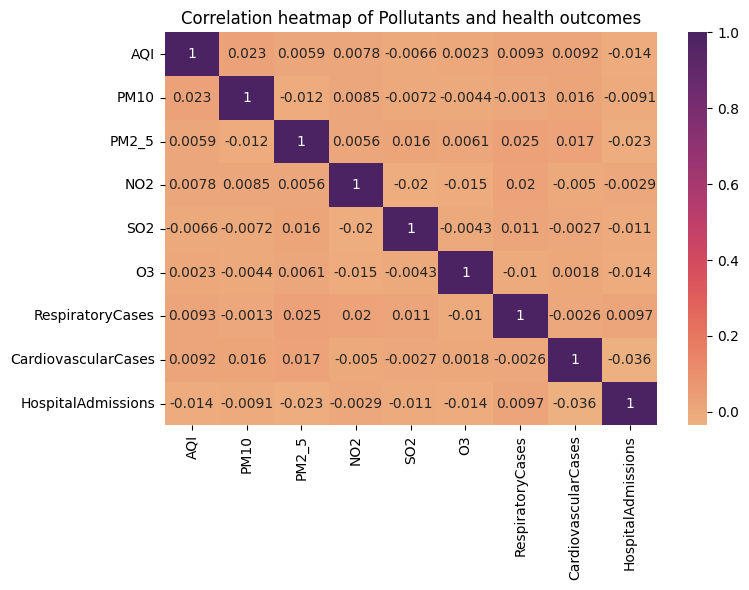

In [23]:
features= ['AQI', 'PM10', 'PM2_5', 'NO2', 'SO2', 'O3',
          'RespiratoryCases', 'CardiovascularCases', 'HospitalAdmissions']
corr_matrix= air_health[features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot= True, cmap= 'flare')
plt.title('Correlation heatmap of Pollutants and health outcomes')
plt.tight_layout()
plt.show()

### **Boxplot camparing Pollutant and Health Impact class**

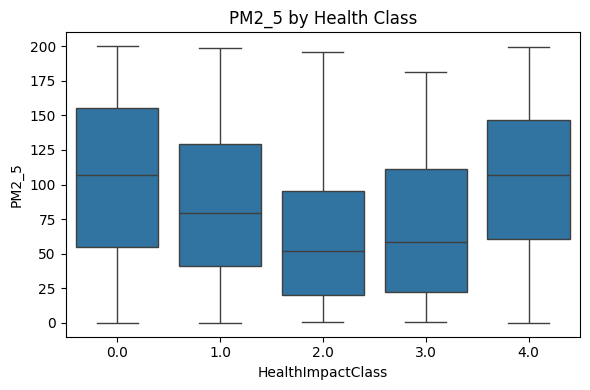

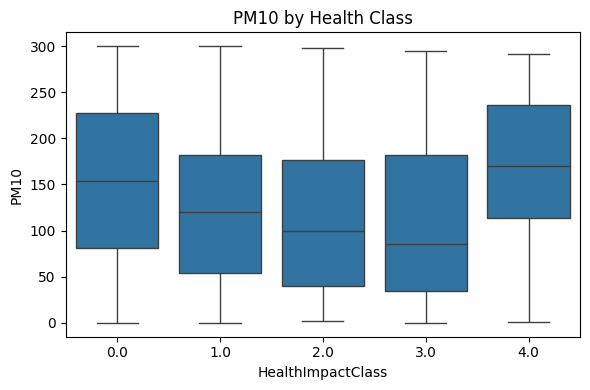

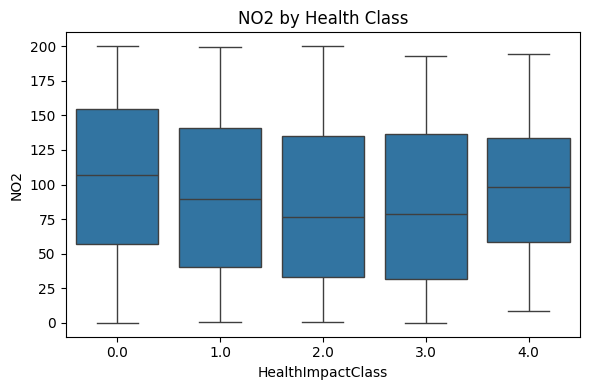

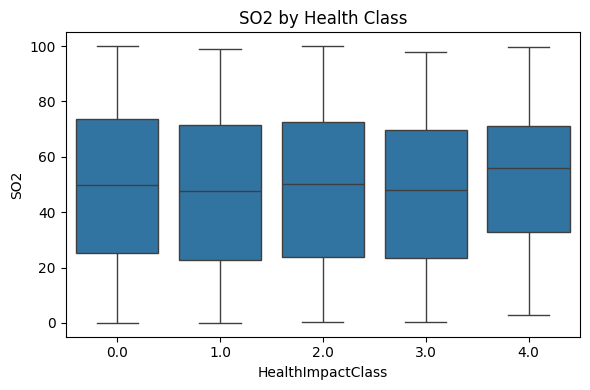

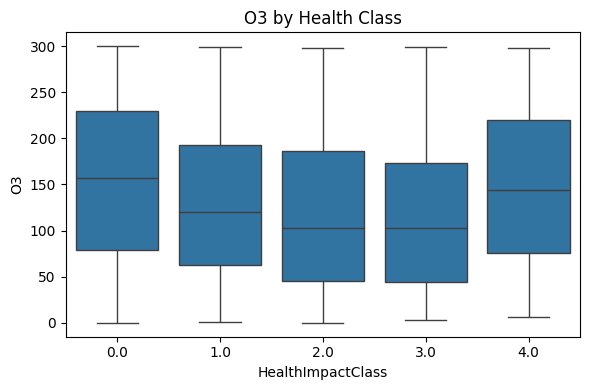

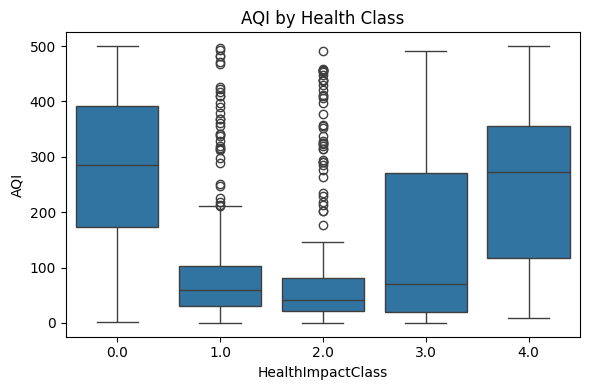

In [24]:
for pollutant in ['PM2_5', 'PM10', 'NO2', 'SO2', 'O3', 'AQI']:
    plt.figure(figsize= (6,4))
    sns.boxplot(x= 'HealthImpactClass', y= pollutant, data= air_health)
    plt.title(f'{pollutant} by Health Class')
    plt.tight_layout()
    plt.show()

**Insights**
Boxplot of AQi vs HealthImpactClass shows many outliers which means:
- AQI value vary widely even within the same health impact class.
- There is extreme pollution events (very high AQI)

### **Seasonal variation effects on air pollution and health cases**

In [25]:
# randomly assigning months and seasons
np.random.seed(42)
air_health['Month']= np.random.choice([
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
], size= len(air_health))

In [26]:
# month to season map
season_dict = {
    'Dec': 'Winter', 'Jan': 'Winter', 'Feb': 'Winter',
    'Mar': 'Spring', 'Apr': 'Spring', 'May': 'Spring',
    'Jun': 'Summer', 'Jul': 'Summer', 'Aug': 'Summer',
    'Sep': 'Fall', 'Oct': 'Fall', 'Nov': 'Fall'
}

air_health['Season'] = air_health['Month'].map(season_dict)

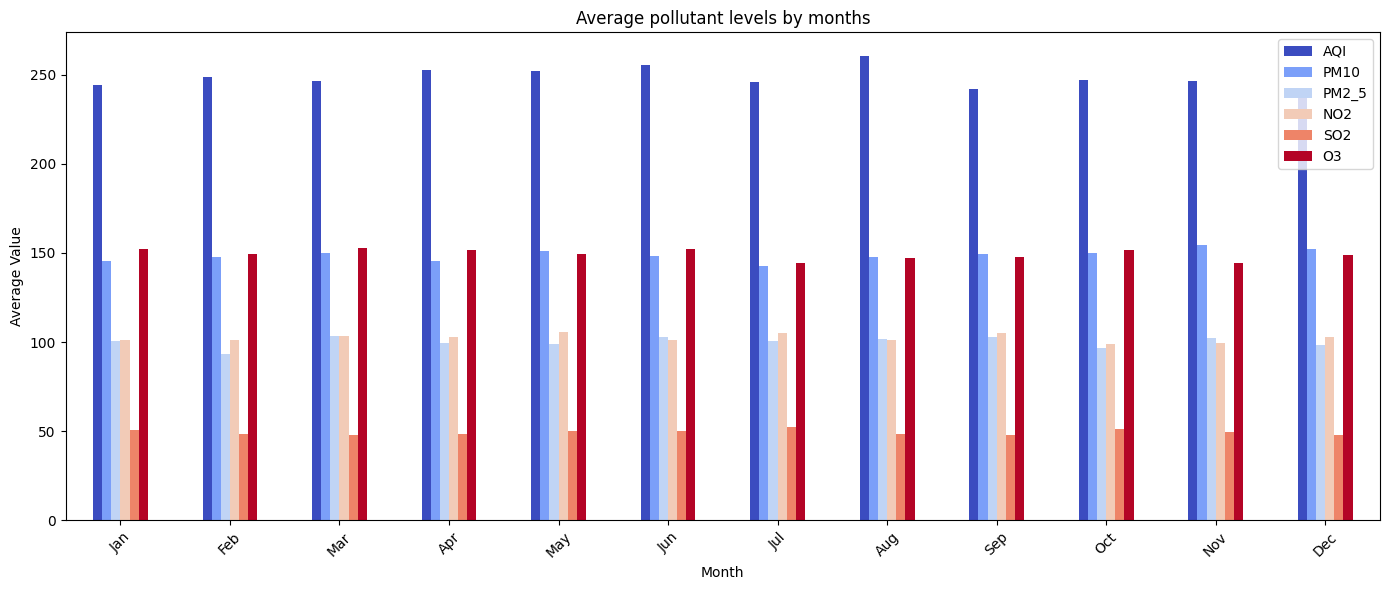

In [27]:
# Month wise pollutant trends
monthAvg= air_health.groupby('Month')[['AQI', 'PM10', 'PM2_5', 'NO2', 'SO2', 'O3']].mean().reindex([
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
])

monthAvg.plot(kind= 'bar', figsize=(14,6), colormap= 'coolwarm')
plt.title('Average pollutant levels by months')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
# average pollutants per season
seasonal_pollution= air_health.groupby('Season')[['PM2_5', 'NO2', 'SO2', 'O3', 'PM10']].mean()

# average health outcomes per person
seasonal_health= air_health.groupby('Season')[['HospitalAdmissions', 'CardiovascularCases', 'RespiratoryCases']].mean()

print("Average pollution per season:\n", seasonal_pollution)
print("Average health cases per season:\n", seasonal_health )

Average pollution per season:
              PM2_5         NO2        SO2          O3        PM10
Season                                                           
Fall    100.754726  101.131692  49.572049  147.744940  151.314284
Spring  100.756648  103.903314  48.897687  151.358499  148.815038
Summer  101.879998  102.370667  50.312928  147.802612  146.139970
Winter   97.573495  101.726238  49.057220  150.256858  148.470283
Average health cases per season:
         HospitalAdmissions  CardiovascularCases  RespiratoryCases
Season                                                           
Fall              2.007868             4.979256         10.003577
Spring            2.017772             4.997266         10.033493
Summer            1.969220             4.993844          9.920657
Winter            2.009409             4.985215          9.940860


### **Seasonal pollution bargraph**

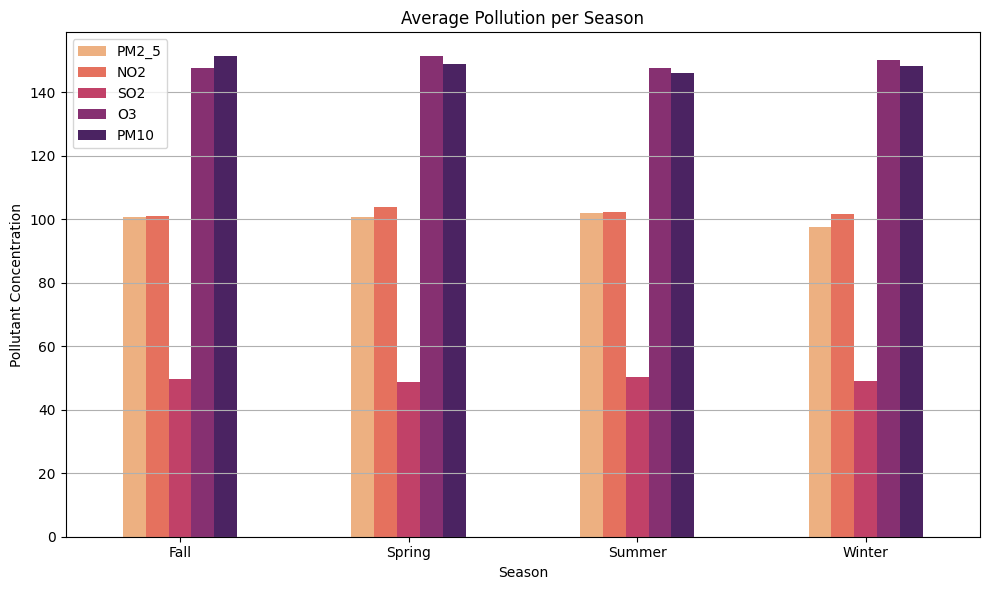

In [29]:
# Barplot: average pollution levels per season
seasonal_pollution.plot(kind= 'bar', figsize=(10,6), title= 'Average Pollution per Season', colormap='flare')
plt.ylabel('Pollutant Concentration')
plt.xlabel('Season')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### **Health Impact across the seasons**

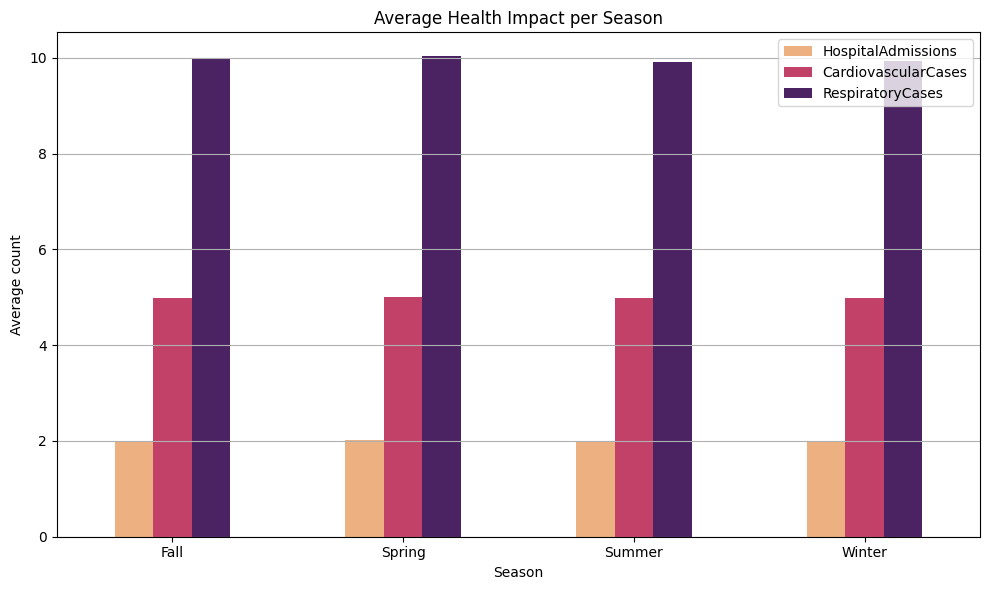

In [30]:
# Barplot: average health outcomes per season
seasonal_health.plot(kind= 'bar', figsize= (10,6), title= 'Average Health Impact per Season', colormap='flare')
plt.ylabel('Average count')
plt.xlabel('Season')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### **Pollutant concentration vs. Hospitalization rate**

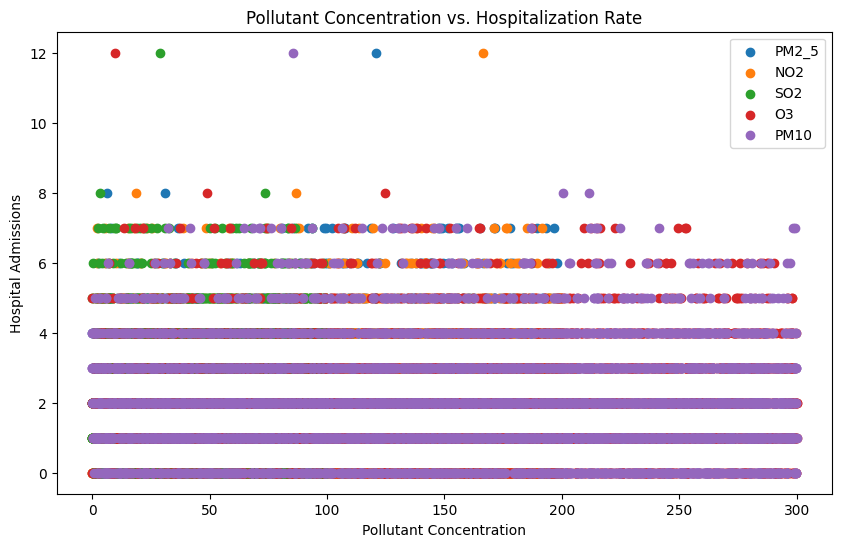

In [31]:
plt.figure(figsize=(10, 6))
pollutants = ["PM2_5", "NO2", "SO2", "O3", "PM10"]

for pollutant in pollutants:
    plt.scatter(df[pollutant], df["HospitalAdmissions"], label=pollutant)

plt.xlabel("Pollutant Concentration")
plt.ylabel("Hospital Admissions")
plt.title("Pollutant Concentration vs. Hospitalization Rate")
plt.legend()
plt.show()

A scatterplot illustrates the realtionship between pollutant concentration and hospitalization rates and shows positive correlation between higher pollution levels and increased hospital admissions.

### **Boxplot showing AQI categories vs. Health Impact Score**

C:\Users\Admin\AppData\Local\Temp\ipykernel_10704\876754595.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=air_health["AQI_Category"], y=air_health["HealthImpactScore"], palette="flare")


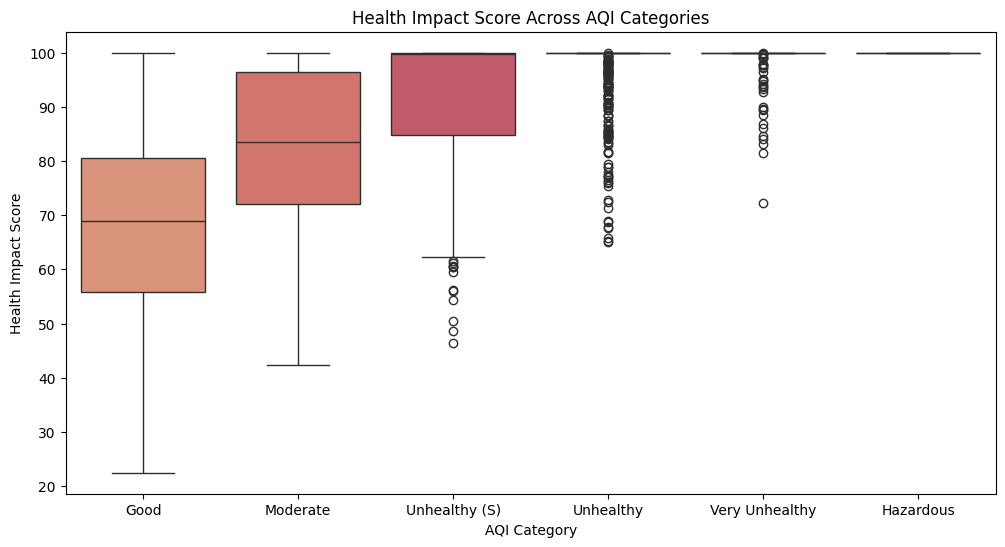

In [32]:
# Define AQI categories
air_health["AQI_Category"] = pd.cut(df["AQI"], bins=[0, 50, 100, 150, 200, 300, 500],
                            labels=["Good", "Moderate", "Unhealthy (S)", "Unhealthy", "Very Unhealthy", "Hazardous"])

# Boxplot of Health Impact Score Across AQI Categories
plt.figure(figsize=(12, 6))
sns.boxplot(x=air_health["AQI_Category"], y=air_health["HealthImpactScore"], palette="flare")
plt.title("Health Impact Score Across AQI Categories")
plt.xlabel("AQI Category")
plt.ylabel("Health Impact Score")
plt.show()

This boxplot show how different AQI levels affect health impact scores and clearly shows the increasing risk as AQI worsens.

## Can we identify high-risk days from weather + pollution?
predict wheather a day is high risk (1) or not (0) using pollution and weather features.

Creating a binary column `is_high_risk` where, `HealthImpactClass >= 3` is considered high risk so that multiclass health impact be converted into a binary classification problem.

### a. Using **RandomForestClassifier**

In [33]:
air_health['is_high_risk']= (air_health['HealthImpactClass']>= 3).astype(int)

# checking how balanced classes are
print(air_health['is_high_risk'].value_counts())

is_high_risk
0    5660
1     151
Name: count, dtype: int64


In [34]:
# These features are predictors (weather + pollution indicators)
features = ['PM10', 'PM2_5', 'NO2', 'SO2', 'O3', 'AQI',
            'Temperature', 'Humidity', 'WindSpeed', 'PollutionIndex']

X = air_health[features]  # Input variables
y = air_health['is_high_risk']  # Binary target variable (0 = not high-risk, 1 = high-risk)

In [35]:
# We split the data into training and testing sets to evaluate the model later on.
# stratify=y ensures both classes (0 and 1) are proportionally represented.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [36]:
# If high-risk days are underrepresented, SMOTE generates synthetic samples to balance the dataset.
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(pd.Series(y_train_smote).value_counts())

is_high_risk
0    3961
1    3961
Name: count, dtype: int64


In [37]:
# Random Forest is robust to noise and can handle non-linear relationships well.
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_smote, y_train_smote)

# Predicting on test data
y_pred = rf.predict(X_test)

### Model evaluation of RandomForestClassifier

In [38]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report of RandomForestClassifier:\n", classification_report(y_test, y_pred))

Accuracy: 0.9501146788990825
Precision: 0.125
Recall: 0.15555555555555556
F1 Score: 0.13861386138613863

Classification Report of RandomForestClassifier:
               precision    recall  f1-score   support

           0       0.98      0.97      0.97      1699
           1       0.12      0.16      0.14        45

    accuracy                           0.95      1744
   macro avg       0.55      0.56      0.56      1744
weighted avg       0.96      0.95      0.95      1744



### b. Using **XGBoostClassifier**

In [ ]:
features = ['PM10', 'PM2_5', 'NO2', 'SO2', 'O3', 'AQI',
            'Temperature', 'Humidity', 'WindSpeed', 'PollutionIndex']

X = air_health[features]  
y = air_health['is_high_risk'] 

# splitting the data to evaluate model performance 
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42, stratify=y)

In [40]:
# Handling class imbalance using SMOTE that creates synthetic samples of the minority class to balance the training set
smote= SMOTE(random_state=42)
X_trained_resampled, y_train_resampled= smote.fit_resample(X_train, y_train)

print("After SMOTE: ")
print(pd.Series(y_train_resampled).value_counts())

After SMOTE: 
is_high_risk
0    4527
1    4527
Name: count, dtype: int64


In [41]:
# defining hyperparamter grid for tuning important parameters to get best model performance
param_grid={
    'n_estimators': [100,200], #no. of trees (higher = more learning power)
    'max_depth': [3,5,7], # how deep the tree can go (too deep= overfitting)
    'learning_rate': [0.01, 0.1, 0.2], # smaller= slower but better learning 
    'subsample': [0.8, 1], # control overfitting
    'colsample_bytree': [0.8, 1], 
    'scale_pos_weight': [1]  
}

# define XGBoost Model
xgb= XGBClassifier(
    objective= 'binary:logistic',
    eval_metric= 'logloss',
    use_label_encoder= False,
    random_state=42
)

In [42]:
# Hyperparameter tuning using GRID search - tries every combination to find the best-performing set
grid= GridSearchCV(estimator=xgb, param_grid= param_grid,
                          scoring='f1_macro', cv=3, verbose=1, n_jobs=-1)

# Fit model
grid.fit(X_trained_resampled, y_train_resampled)

# Best estimator
best_model= grid.best_estimator_
print("Best parameters: ", grid.best_params_)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:03:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters:  {'colsample_bytree': 1, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'scale_pos_weight': 1, 'subsample': 0.8}


### Model evaluation of XGBoostClassifier

In [43]:
# model evaluation on test set
y_pred= best_model.predict(X_test)

acc= accuracy_score(y_test, y_pred)
prec= precision_score(y_test, y_pred,average="weighted", zero_division=0)
recall= recall_score(y_test, y_pred, average= 'weighted')
f1= f1_score(y_test, y_pred, average='weighted')

print("\n Evaluation metrics:")
print("Accuracy: ", acc)
print("Precision: ", prec)
print("Recall: ", recall)
print("F1 Score", f1)

print("\n Classification Report of XGBoostClassifier: \n", classification_report(y_test, y_pred))


 Evaluation metrics:
Accuracy:  0.9475494411006019
Precision:  0.9581754771320651
Recall:  0.9475494411006019
F1 Score 0.952619739464222

 Classification Report of XGBoostClassifier: 
               precision    recall  f1-score   support

           0       0.98      0.97      0.97      1133
           1       0.16      0.23      0.19        30

    accuracy                           0.95      1163
   macro avg       0.57      0.60      0.58      1163
weighted avg       0.96      0.95      0.95      1163



### ROC Curve and Confusion matrix for **Random Forest Classifier**

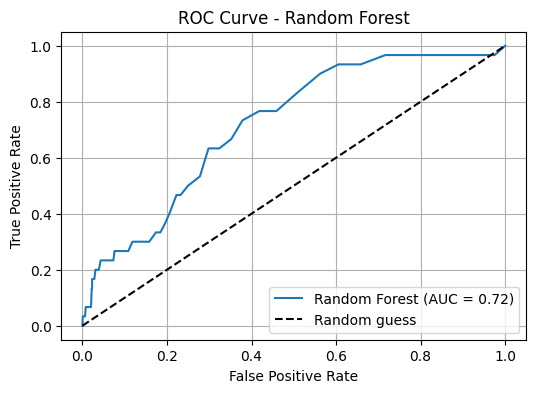

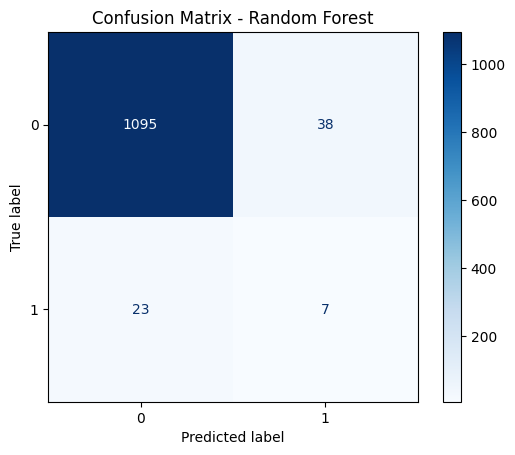

In [57]:
# ROC Curve
y_prob_rf = rf.predict_proba(X_test)[:, 1]  # Probabilities for class 1
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(6, 4))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.grid()
plt.show()

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.show()

### ROC and Confusion matric for **XGBoostClassifier**

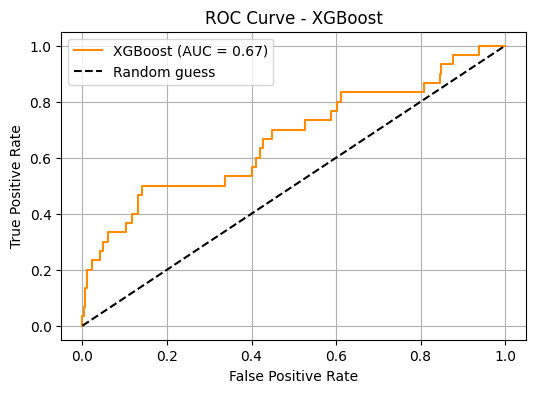

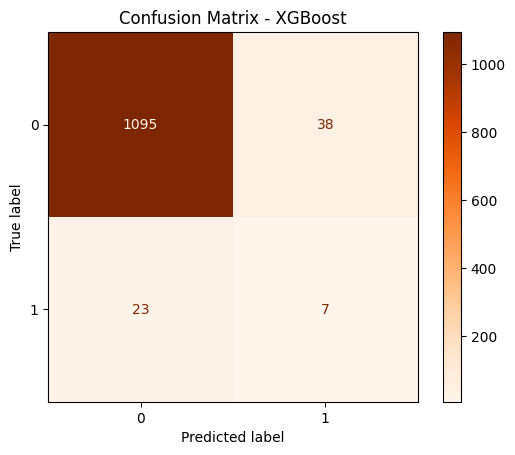

In [58]:
# ROC Curve
y_prob_xgb = best_model.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

plt.figure(figsize=(6, 4))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.grid()
plt.show()

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp_xgb.plot(cmap='Oranges')
plt.title('Confusion Matrix - XGBoost')
plt.show()

### c. Using **K-means clustering**

In [44]:
# Select and cleaning only numeric features
air_health_cleaned = air_health.select_dtypes(include=['float64', 'int64']).copy()
air_health_cleaned.drop(columns=['RecordID'], errors='ignore', inplace=True)

# Scaling the data as KMeans is distance based 
scaler = StandardScaler()
scaled_data = scaler.fit_transform(air_health_cleaned)

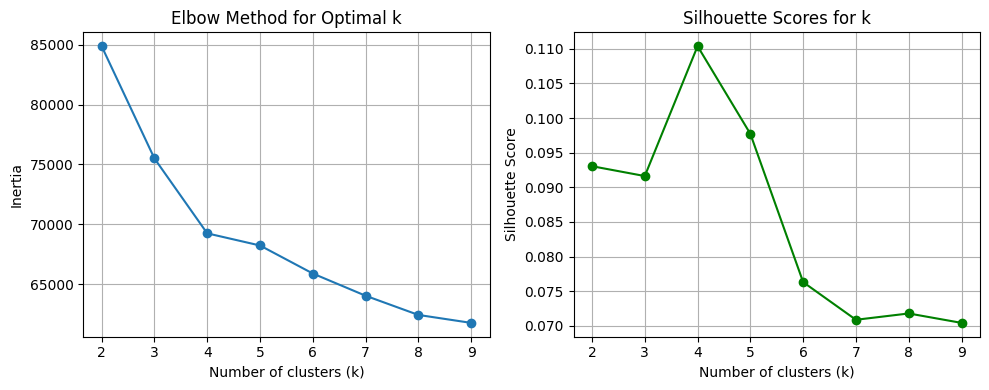

In [45]:
# Elbow Method
inertia = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_data)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_data, labels))

# Plot Elbow Curve
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o', color='green')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for k')
plt.grid(True)

plt.tight_layout()
plt.show()

`k=3` as eblow starts from 3, and 3 has highest silhouette score.

In [46]:
# applying KMeans clustering 
kmeans= KMeans(n_clusters=3, random_state=42)
air_health['Cluster']= kmeans.fit_predict(scaled_data)

In [47]:
# based on Cluster mean, labeling the clusters
cluster_means= air_health.groupby('Cluster')['PollutionIndex'].mean().sort_values()
risk_mapping= {
    cluster_means.index[0]: 'Low Risk',
    cluster_means.index[1]: 'Moderate Risk',
    cluster_means.index[2]: 'High Risk'
}

air_health['Cluster_label']= air_health['Cluster'].map(risk_mapping)

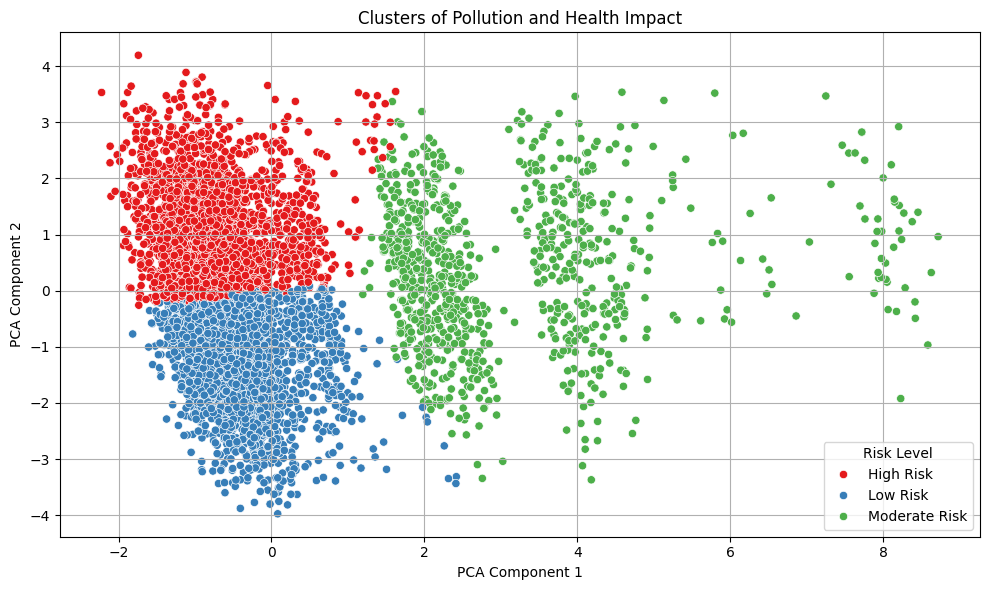

In [48]:
# visualize with PCA
pca= PCA(n_components= 2)
pca_components= pca.fit_transform(scaled_data)
air_health['PCA1']= pca_components[:, 0]
air_health['PCA2'] = pca_components[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster_label', data=air_health, palette='Set1')
plt.title("Clusters of Pollution and Health Impact")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Risk Level")
plt.grid(True)
plt.tight_layout()
plt.show()

### Finding Anomalous high-risk days with **DBSCAN**

In [49]:
# initializing DBSCAN
dbscan= DBSCAN(eps=3.0, min_samples=5)
db_labels= dbscan.fit_predict(scaled_data)

# adding cluster labels to dataframe
air_health['DBSCAN_Cluster'] = db_labels

In [50]:
# DBSCAN assigns -1 to noise points (anomalies)
air_health['IsAnomalous']= air_health['DBSCAN_Cluster'] == -1

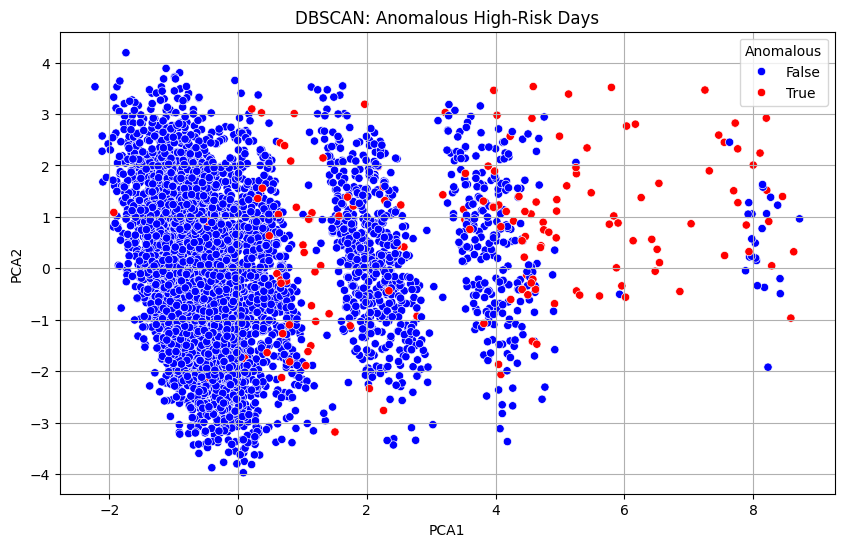

In [51]:
# Visualize Anomalies
plt.figure(figsize=(10, 6))
sns.scatterplot(data=air_health, x='PCA1', y='PCA2', hue='IsAnomalous',
                palette={True: 'red', False: 'blue'})
plt.title("DBSCAN: Anomalous High-Risk Days")
plt.grid(True)
plt.legend(title='Anomalous')
plt.show()

### Using **Isolation forest** to validate DBSCAN

In [52]:
# initializing the model
model_Iso= IsolationForest(contamination=0.01, random_state=42)

iso_pred= model_Iso.fit_predict(scaled_data)  # this model assigns -1 to anomallies and 1 to normal points

In [53]:
# adding Anomaly labels to dataframe
air_health['IForest_Anomalous'] = iso_pred == -1

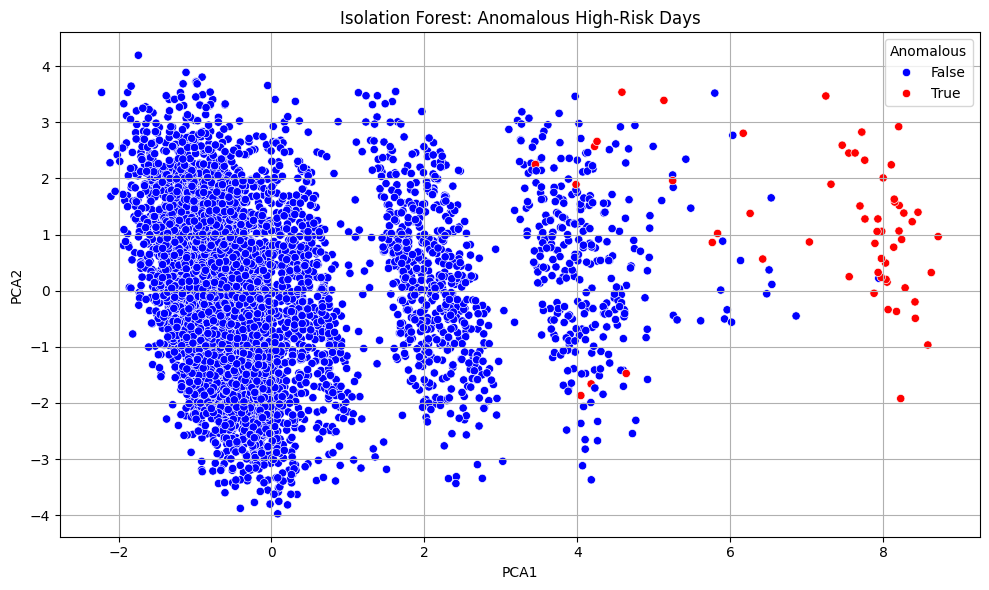

In [54]:
# visualize anomalies
plt.figure(figsize=(10,6))
sns.scatterplot(data=air_health, x='PCA1', y='PCA2', hue='IForest_Anomalous',
                palette={True: 'red', False: 'blue'})
plt.title("Isolation Forest: Anomalous High-Risk Days")
plt.grid(True)
plt.legend(title='Anomalous')
plt.tight_layout()
plt.show()

### Comparision between DBSCAN and Isolation forest Anomalies

In [55]:
com= (air_health['IsAnomalous'] & air_health['IForest_Anomalous']).sum()
total_anomalies = air_health['IForest_Anomalous'].sum()
anomalies_dbscan = air_health['IsAnomalous'].sum()

print(f"Number of points identified as anomalous by both DBSCAN and Isolation Forest: {com}")
print(f"Total anomalies by Isolation Forest: {total_anomalies}")
print(f"Total anomalies by DBSCAN: {anomalies_dbscan}")

Number of points identified as anomalous by both DBSCAN and Isolation Forest: 34
Total anomalies by Isolation Forest: 59
Total anomalies by DBSCAN: 160
